# Task 2 - Restaurant Recommendation System

## Import Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## Load Dataset

In [65]:
df = pd.read_csv(r"C:\Users\My PC\Downloads\Dataset .csv", encoding='latin1')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
df.head()

Dataset Shape: (9551, 21)

Columns:
['ï»¿Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Basic Info & Summary

In [67]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ï»¿Restaurant ID      9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  

,ï»¿Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Check Missing Values

In [69]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': round(missing_pct, 2)
})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
          Missing Count  Percentage (%)
Cuisines              9            0.09


## Preprocessing: Handle Missing Values & Clean Data

In [71]:
df_clean = df.copy()

# Fix BOM character in column names if present
df_clean.columns = df_clean.columns.str.replace('ï»¿', '', regex=False).str.strip()

# Remove unrated restaurants
df_clean = df_clean[df_clean['Aggregate rating'] > 0].copy()
print(f"Rated restaurants kept: {len(df_clean)}")

# Fill missing Cuisines
df_clean['Cuisines'].fillna('Unknown', inplace=True)

# Fill other missing values
df_clean['Average Cost for two'].fillna(df_clean['Average Cost for two'].median(), inplace=True)

print(f"Missing values remaining: {df_clean.isnull().sum().sum()}")
df_clean.head()

Rated restaurants kept: 7403
Missing values remaining: 0


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Encode Categorical Variables

In [73]:
df_encoded = df_clean.copy()

le = LabelEncoder()

# Encode key categorical columns
cat_cols = ['City', 'Cuisines', 'Currency',
            'Has Table booking', 'Has Online delivery',
            'Is delivering now']

for col in cat_cols:
    if col in df_encoded.columns:
        df_encoded[col + '_enc'] = le.fit_transform(df_encoded[col].astype(str))
        print(f"Encoded: {col}")

print("\nEncoding complete!")

Encoded: City
Encoded: Cuisines
Encoded: Currency
Encoded: Has Table booking
Encoded: Has Online delivery
Encoded: Is delivering now

Encoding complete!


## Select Features for Recommendation

In [75]:
# Features used to compute similarity between restaurants
feature_cols = [
    'City_enc', 'Cuisines_enc',
    'Average Cost for two', 'Price range',
    'Has Table booking_enc', 'Has Online delivery_enc',
    'Is delivering now_enc', 'Aggregate rating', 'Votes'
]

# Keep only existing columns
feature_cols = [col for col in feature_cols if col in df_encoded.columns]
print(f"Features used: {feature_cols}")

# Build feature matrix
feature_matrix = df_encoded[feature_cols].copy()

# Normalize features to [0, 1]
scaler = MinMaxScaler()
feature_matrix_scaled = scaler.fit_transform(feature_matrix)

print(f"\nFeature matrix shape: {feature_matrix_scaled.shape}")

Features used: ['City_enc', 'Cuisines_enc', 'Average Cost for two', 'Price range', 'Has Table booking_enc', 'Has Online delivery_enc', 'Is delivering now_enc', 'Aggregate rating', 'Votes']

Feature matrix shape: (7403, 9)


## Compute Cosine Similarity Matrix

In [77]:
# Compute cosine similarity between all restaurants
cosine_sim = cosine_similarity(feature_matrix_scaled)

print(f"Similarity matrix shape: {cosine_sim.shape}")
print("\nSample similarity scores (first 5 restaurants):")
print(pd.DataFrame(cosine_sim[:5, :5]).round(3))

Similarity matrix shape: (7403, 7403)

Sample similarity scores (first 5 restaurants):
       0      1      2      3      4
0  1.000  0.996  0.965  0.799  0.987
1  0.996  1.000  0.980  0.796  0.988
2  0.965  0.980  1.000  0.842  0.986
3  0.799  0.796  0.842  1.000  0.850
4  0.987  0.988  0.986  0.850  1.000


## Build Recommendation Function

In [79]:
def recommend_restaurants(user_preferences, df, feature_matrix_scaled,
                           cosine_sim, top_n=5):
    """
    Recommend restaurants based on user preferences.

    Parameters:
    -----------
    user_preferences : dict with keys like:
        - 'cuisine'    : str  (e.g., 'Italian')
        - 'city'       : str  (e.g., 'New Delhi')
        - 'price_range': int  (1=cheap, 2=moderate, 3=expensive, 4=luxury)
        - 'online_delivery': str ('Yes' or 'No')
        - 'table_booking'  : str ('Yes' or 'No')
        - 'min_rating' : float (minimum acceptable rating)
    top_n : int — number of recommendations to return
    """

    filtered = df.copy()

    # Filter by city
    if 'city' in user_preferences and user_preferences['city']:
        filtered = filtered[filtered['City'].str.lower() ==
                            user_preferences['city'].lower()]

    # Filter by cuisine (partial match)
    if 'cuisine' in user_preferences and user_preferences['cuisine']:
        filtered = filtered[filtered['Cuisines'].str.contains(
            user_preferences['cuisine'], case=False, na=False)]

    # Filter by price range
    if 'price_range' in user_preferences and user_preferences['price_range']:
        filtered = filtered[filtered['Price range'] ==
                            user_preferences['price_range']]

    # Filter by online delivery
    if 'online_delivery' in user_preferences and user_preferences['online_delivery']:
        filtered = filtered[filtered['Has Online delivery'] ==
                            user_preferences['online_delivery']]

    # Filter by table booking
    if 'table_booking' in user_preferences and user_preferences['table_booking']:
        filtered = filtered[filtered['Has Table booking'] ==
                            user_preferences['table_booking']]

    # Filter by minimum rating
    if 'min_rating' in user_preferences and user_preferences['min_rating']:
        filtered = filtered[filtered['Aggregate rating'] >=
                            user_preferences['min_rating']]

    if filtered.empty:
        print("⚠️ No restaurants found matching your preferences.")
        print("Try relaxing some filters (e.g., remove city or cuisine filter).")
        return pd.DataFrame()

    # Sort by rating and votes
    result = filtered.sort_values(
        by=['Aggregate rating', 'Votes'], ascending=False
    ).head(top_n)

    # Select display columns
    display_cols = ['Restaurant Name', 'City', 'Cuisines',
                    'Average Cost for two', 'Price range',
                    'Has Table booking', 'Has Online delivery',
                    'Aggregate rating', 'Votes', 'Rating text']
    display_cols = [c for c in display_cols if c in result.columns]

    return result[display_cols].reset_index(drop=True)


print("Recommendation function defined successfully!")

Recommendation function defined successfully!


## Test 1: Recommend by Cuisine & City

In [81]:
# --- User Preference Test 1 ---
user_pref_1 = {
    'city'     : 'New Delhi',
    'cuisine'  : 'North Indian',
    'min_rating': 4.0
}

print("=== User Preferences ===")
for k, v in user_pref_1.items():
    print(f"  {k}: {v}")

print("\n=== Top Restaurant Recommendations ===")
recommendations_1 = recommend_restaurants(
    user_pref_1, df_encoded,
    feature_matrix_scaled, cosine_sim, top_n=5
)
recommendations_1

=== User Preferences ===
  city: New Delhi
  cuisine: North Indian
  min_rating: 4.0

=== Top Restaurant Recommendations ===


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Table booking,Has Online delivery,Aggregate rating,Votes,Rating text
0,Kopper Kadai,New Delhi,North Indian,1400,3,No,No,4.8,83,Excellent
1,Zabardast Indian Kitchen,New Delhi,North Indian,1800,3,Yes,Yes,4.7,242,Excellent
2,Band Baaja Baaraat,New Delhi,North Indian,1300,3,Yes,No,4.6,128,Excellent
3,Food Scouts,New Delhi,"North Indian, Chinese, Continental",700,2,No,Yes,4.6,61,Excellent
4,Cafe Lota,New Delhi,"North Indian, South Indian, Bihari",1200,3,No,No,4.5,2213,Excellent


## Test 2: Recommend by Price Range & Online Delivery

In [83]:
# --- User Preference Test 2 ---
user_pref_2 = {
    'city'             : 'New Delhi',
    'price_range'      : 2,          # 1=cheap 2=moderate 3=expensive 4=luxury
    'online_delivery'  : 'Yes',
    'min_rating'       : 3.5
}

print("=== User Preferences ===")
for k, v in user_pref_2.items():
    print(f"  {k}: {v}")

print("\n=== Top Restaurant Recommendations ===")
recommendations_2 = recommend_restaurants(
    user_pref_2, df_encoded,
    feature_matrix_scaled, cosine_sim, top_n=5
)
recommendations_2

=== User Preferences ===
  city: New Delhi
  price_range: 2
  online_delivery: Yes
  min_rating: 3.5

=== Top Restaurant Recommendations ===


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Table booking,Has Online delivery,Aggregate rating,Votes,Rating text
0,Spezia Bistro,New Delhi,"Cafe, Continental, Chinese, Italian",900,2,Yes,Yes,4.6,1071,Excellent
1,Food Scouts,New Delhi,"North Indian, Chinese, Continental",700,2,No,Yes,4.6,61,Excellent
2,Midnight Hunger Hub,New Delhi,"North Indian, Fast Food, Italian, Asian",800,2,No,Yes,4.5,50,Excellent
3,The Hudson Cafe,New Delhi,"Cafe, Italian, Continental, Chinese",850,2,No,Yes,4.4,1537,Very Good
4,Food Scouts,New Delhi,"North Indian, Chinese, Continental",700,2,No,Yes,4.4,229,Very Good


## Test 3: Recommend with Table Booking & High Rating

In [85]:
# --- User Preference Test 3 ---
user_pref_3 = {
    'city'          : 'New Delhi',
    'cuisine'       : 'Chinese',
    'table_booking' : 'Yes',
    'min_rating'    : 4.5
}

print("=== User Preferences ===")
for k, v in user_pref_3.items():
    print(f"  {k}: {v}")

print("\n=== Top Restaurant Recommendations ===")
recommendations_3 = recommend_restaurants(
    user_pref_3, df_encoded,
    feature_matrix_scaled, cosine_sim, top_n=5
)
recommendations_3

=== User Preferences ===
  city: New Delhi
  cuisine: Chinese
  table_booking: Yes
  min_rating: 4.5

=== Top Restaurant Recommendations ===


,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Has Table booking,Has Online delivery,Aggregate rating,Votes,Rating text
0,Spezia Bistro,New Delhi,"Cafe, Continental, Chinese, Italian",900,2,Yes,Yes,4.6,1071,Excellent
1,Qubitos - The Terrace Cafe,New Delhi,"Thai, European, Mexican, North Indian, Chinese...",1500,3,Yes,No,4.5,778,Excellent


## Content-Based Filtering: Similar Restaurants

In [87]:
def get_similar_restaurants(restaurant_name, df, cosine_sim, top_n=5):
    """
    Given a restaurant name, find the most similar restaurants
    using cosine similarity on features.
    """
    # Find index
    matches = df[df['Restaurant Name'].str.lower() ==
                 restaurant_name.lower()]
    if matches.empty:
        print(f"Restaurant '{restaurant_name}' not found in dataset.")
        return pd.DataFrame()

    idx = matches.index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]  # exclude itself

    restaurant_indices = [i[0] for i in sim_scores]
    similarity_values  = [round(i[1], 4) for i in sim_scores]

    display_cols = ['Restaurant Name', 'City', 'Cuisines',
                    'Average Cost for two', 'Price range',
                    'Aggregate rating', 'Votes']
    display_cols = [c for c in display_cols if c in df.columns]

    result = df.iloc[restaurant_indices][display_cols].copy()
    result.insert(0, 'Similarity Score', similarity_values)
    return result.reset_index(drop=True)


print("Similar restaurant function defined!")

Similar restaurant function defined!


## Test Similar Restaurants

In [89]:
# Enter any restaurant name from the dataset
restaurant_input = df_encoded['Restaurant Name'].iloc[0]
print(f"Finding restaurants similar to: '{restaurant_input}'\n")

similar = get_similar_restaurants(
    restaurant_input, df_encoded, cosine_sim, top_n=5
)
similar

Finding restaurants similar to: 'Le Petit Souffle'



,Similarity Score,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Aggregate rating,Votes
0,0.9979,Roti Chai,London,"Indian, Street Food",45,3,4.5,367
1,0.9963,Izakaya Kikufuji,Makati City,Japanese,1200,3,4.5,591
2,0.9962,Locavore,Pasig City,Filipino,1100,3,4.8,532
3,0.9949,Mr Cooper's House & Garden - The Midland,Manchester,"European, Mediterranean, Contemporary",55,3,4.2,67
4,0.9940,Matchbox,Gurgaon,"Continental, North Indian, Chinese",1500,3,4.8,245


## Visualize: Top Cuisines in Dataset

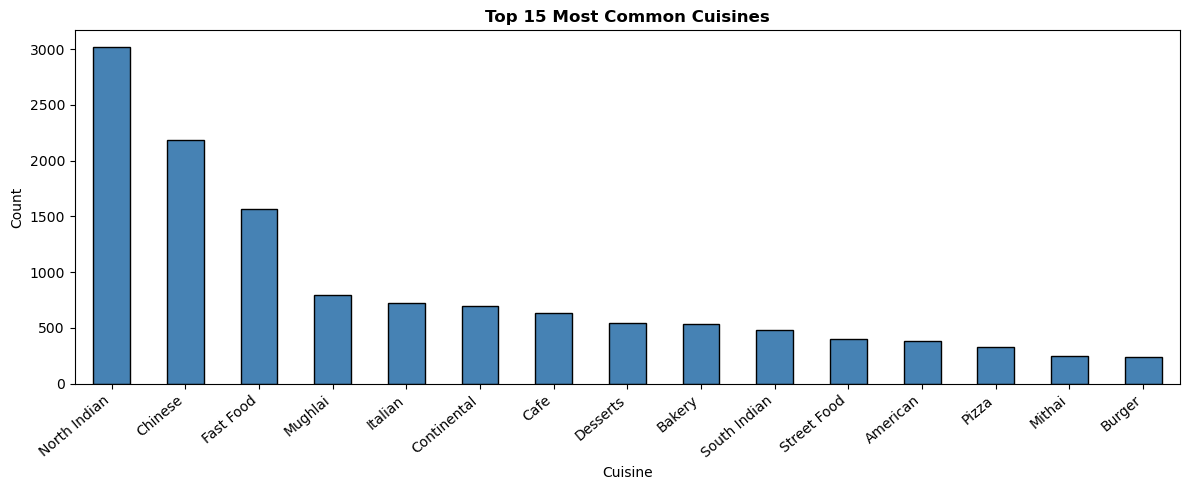

In [91]:
plt.figure(figsize=(12, 5))

top_cuisines = df_clean['Cuisines'].str.split(',').explode().str.strip()
top_cuisines.value_counts().head(15).plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Top 15 Most Common Cuisines', fontweight='bold')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

## Visualize: Rating Distribution by Price Range

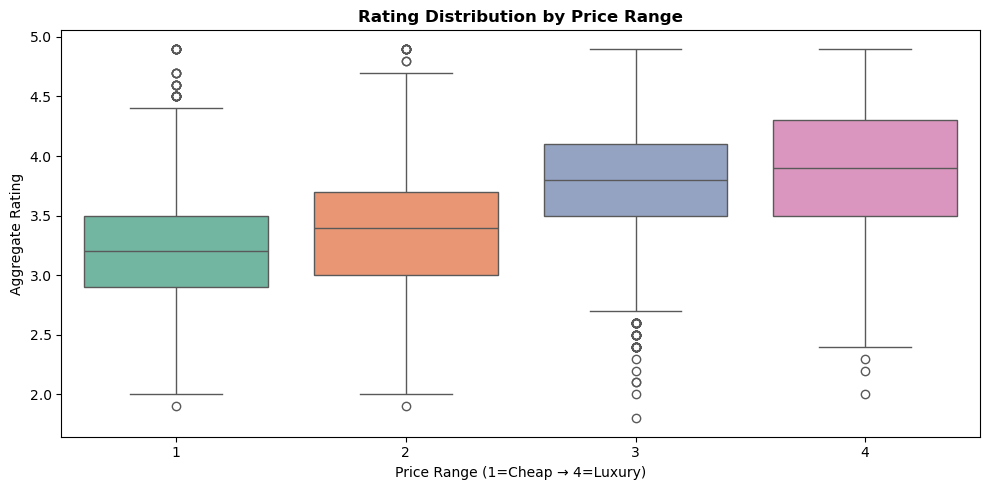

In [93]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Price range', y='Aggregate rating',
            palette='Set2')
plt.title('Rating Distribution by Price Range', fontweight='bold')
plt.xlabel('Price Range (1=Cheap → 4=Luxury)')
plt.ylabel('Aggregate Rating')
plt.tight_layout()
plt.show()

## Visualize: Online Delivery vs Rating

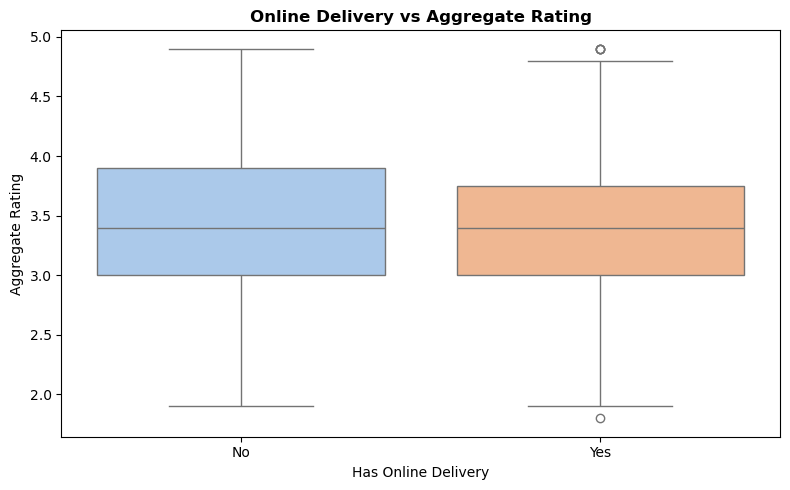

In [95]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x='Has Online delivery',
            y='Aggregate rating', palette='pastel')
plt.title('Online Delivery vs Aggregate Rating', fontweight='bold')
plt.xlabel('Has Online Delivery')
plt.ylabel('Aggregate Rating')
plt.tight_layout()
plt.show()

## Visualize: Top 10 Cities by Number of Restaurants

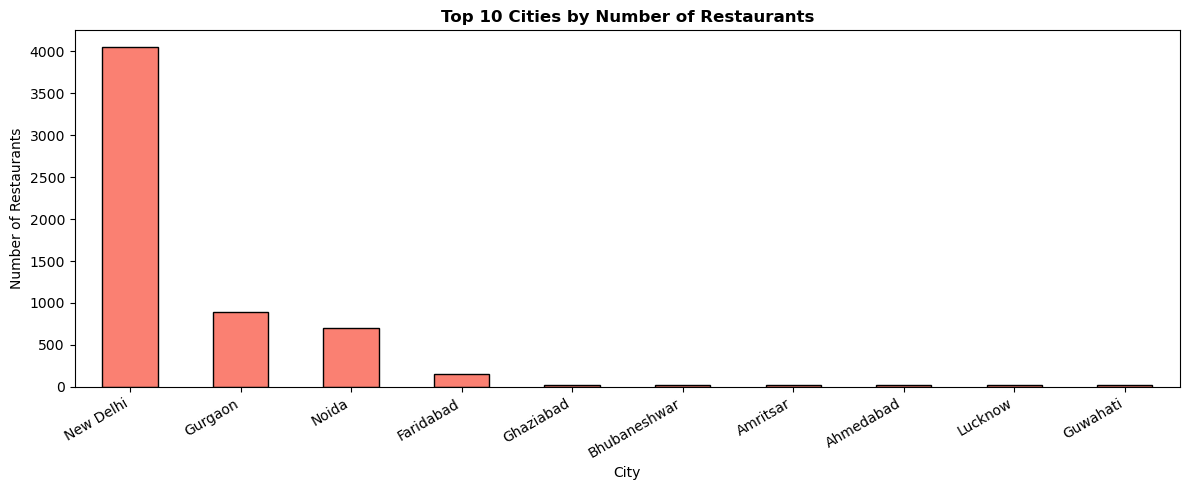

In [97]:
plt.figure(figsize=(12, 5))
df_clean['City'].value_counts().head(10).plot(
    kind='bar', color='salmon', edgecolor='black'
)
plt.title('Top 10 Cities by Number of Restaurants', fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()